In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
df = pd.read_csv("data/raw/employees.csv")

In [8]:
df.head()

,employee_id,application_id,company_id,department,role_family,join_date,monthly_salary_lakhs,work_mode,manager_flag
0,1,53887,140,Data,Software Engineering,2025-02-18 13:50:43,3.849,Onsite,0
1,2,285866,34,Finance,Product Management,2020-06-08 13:27:52,0.680,Onsite,0
2,3,230246,173,Data,Software Engineering,2023-01-25 03:12:58,2.750,Onsite,0
3,4,108668,13,Product,MLOps,2022-06-17 21:14:36,2.736,Onsite,0
4,5,190027,150,HR,DevOps,2020-05-29 01:52:51,0.529,Onsite,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43220 entries, 0 to 43219
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           43220 non-null  int64  
 1   application_id        43220 non-null  int64  
 2   company_id            43220 non-null  int64  
 3   department            43220 non-null  object 
 4   role_family           43220 non-null  object 
 5   join_date             43220 non-null  object 
 6   monthly_salary_lakhs  43220 non-null  float64
 7   work_mode             43220 non-null  object 
 8   manager_flag          43220 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 3.0+ MB


In [10]:
print(df.shape)

(43220, 9)


In [11]:
print(df.columns)

Index(['employee_id', 'application_id', 'company_id', 'department',
       'role_family', 'join_date', 'monthly_salary_lakhs', 'work_mode',
       'manager_flag'],
      dtype='object')


In [12]:
df.isnull().sum()

employee_id             0
application_id          0
company_id              0
department              0
role_family             0
join_date               0
monthly_salary_lakhs    0
work_mode               0
manager_flag            0
dtype: int64

In [13]:
df = df.drop_duplicates()

In [15]:
df = df.ffill()

In [16]:
df.to_csv(
    "data/cleaned/cleaned_employees.csv",
    index=False
)

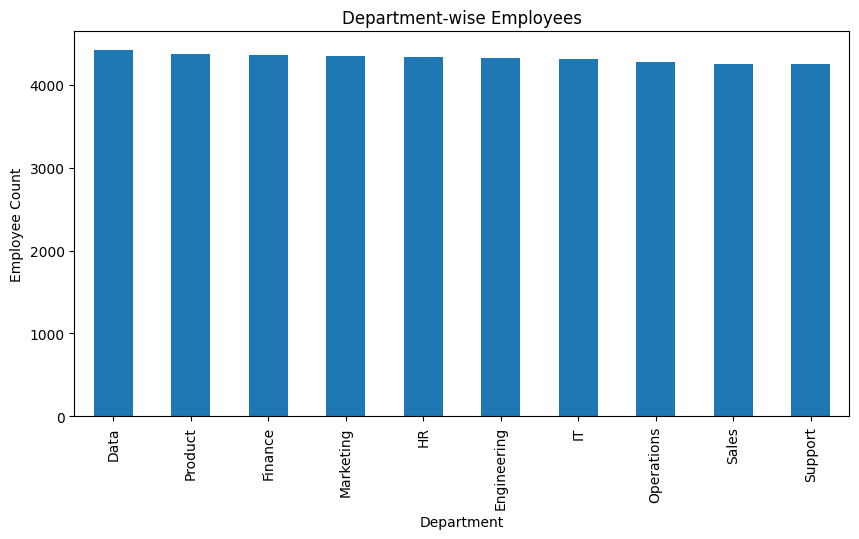

In [17]:
plt.figure(figsize=(10,5))

df['department'].value_counts().plot(kind='bar')

plt.title("Department-wise Employees")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.show()

In [38]:
department_count = df['department'].value_counts()

fig = px.bar(
    x=department_count.index,
    y=department_count.values,
    labels={
        'x': 'Department',
        'y': 'Employee Count'
    },
    title='Employees by Department',
    text=department_count.values
)

fig.update_traces(textposition='outside')

fig.show()

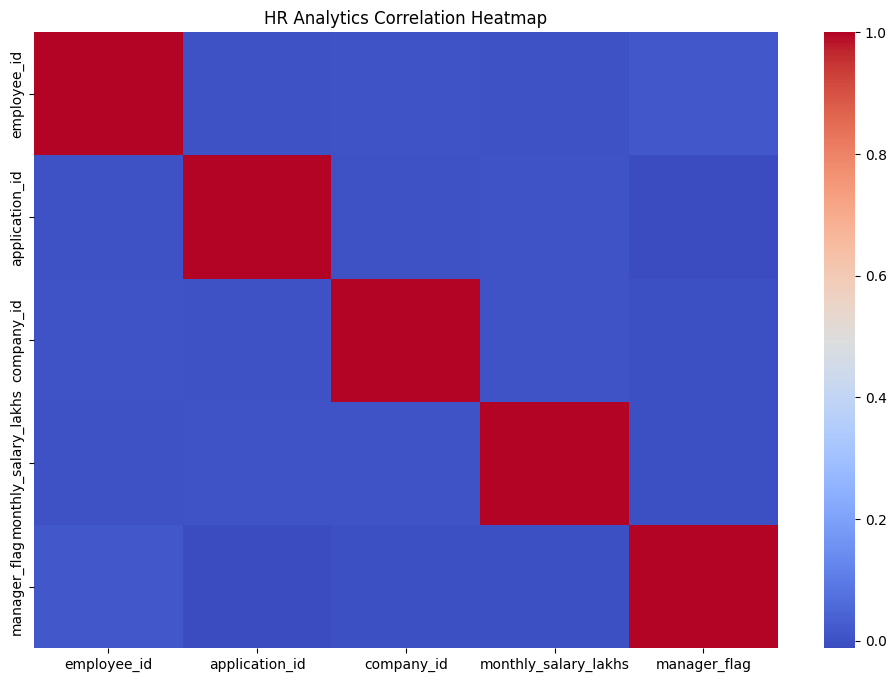

In [39]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("HR Analytics Correlation Heatmap")

plt.show()